# Radish NEXRAD Level 2 — smoke test

Open a NEXRAD Archive II file with radish via the xarray backend, inspect the result, and compare to xradar to confirm parity.

**Prerequisites**

- Build the Python extension once with `cd python && maturin develop --release`
- Set `FIXTURE` below to the absolute path of an Archive II file (`KXXX########_######_V06` or `*.ar2v`)

Everything else is automatic.


In [1]:
from pathlib import Path

FIXTURE = Path('/home/alfonso-ladino/python/raw2zarr/data/KLOT20260310_231412_V06')
assert FIXTURE.exists(), f'Set FIXTURE to a real file. {FIXTURE} not found.'
print(f'Fixture: {FIXTURE.name}  ({FIXTURE.stat().st_size / 1e6:.1f} MB)')

Fixture: KLOT20260310_231412_V06  (8.0 MB)


## 1. The simplest possible open

Radish registers itself as the xarray engine `radish`, so `xr.open_datatree(path, engine='radish')` is all you need. Format detection (CfRadial1 vs NEXRAD AR2V) happens automatically inside the backend.

In [3]:
import xarray as xr
import numpy as np
import xradar as xd

In [13]:
dtrs = xr.open_datatree(FIXTURE, engine='radish')

In [9]:
dt = xd.io.open_nexradlevel2_datatree(FIXTURE)

In [10]:
xr.DataTree.equals(dtrs, dt)

False

## 2. Inspect the volume

Each NEXRAD elevation cut becomes a `/sweep_N` group. Root attributes mirror xradar's NEXRAD shape (instrument_name, scan_name, vcp, source, ...).

In [3]:
print(f"Sweeps: {sum(1 for k in dt.children if k.startswith('sweep_'))}\n")

print('Root attrs:')
for k, v in dt.attrs.items():
    print(f'  {k!r:<20} {v!r}')

Sweeps: 19

Root attrs:
  'instrument_name'    'KLOT'
  'Conventions'        'ODIM_H5/V2_2'
  'version'            ''
  'title'              ''
  'institution'        'NOAA/NWS'
  'references'         ''
  'source'             'NEXRAD Level 2 Archive'
  'history'            ''
  'comment'            ''
  'scan_name'          'VCP-212'
  'vcp'                '212'
  'vcp_description'    'Precipitation, SZ-2'


## 3. Look at one sweep

Each sweep is a regular `xarray.Dataset` you can index and plot like any other.

In [4]:
s0 = dt['/sweep_0']
print('Variables:', list(s0.data_vars))
print('Coords:   ', list(s0.coords))
print('Dims:     ', dict(s0.sizes))
print()
s0

Variables: ['DBZH', 'PHIDP', 'RHOHV', 'ZDR']
Coords:    ['azimuth', 'elevation', 'range']
Dims:      {'sweep': 19, 'time': 720, 'range': 1832}



<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:    (sweep: 19, time: 720, range: 1832)
    Coordinates:
        azimuth    (time) float32 3kB ...
        elevation  (time) float32 3kB ...
      * range      (range) float32 7kB 2.125e+03 2.375e+03 ... 4.596e+05 4.599e+05
    Dimensions without coordinates: sweep, time
    Data variables:
        DBZH       (time, range) float32 5MB ...
        PHIDP      (time, range) float32 5MB ...
        RHOHV      (time, range) float32 5MB ...
        ZDR        (time, range) float32 5MB ...
    Attributes:
        sweep_number:     1
        fixed_angle:      0.52734375
        instrument_name:  KLOT

In [5]:
# A specific moment
if 'DBZH' in s0.data_vars:
    dbzh = s0['DBZH']
    print(f'DBZH shape={dbzh.shape}  dtype={dbzh.dtype}  units={dbzh.attrs.get("units", "?")}')
    valid = np.isfinite(dbzh.values)
    print(f'  valid gates: {valid.sum():,}/{valid.size:,}  '
          f'min={np.nanmin(dbzh.values):.1f}  max={np.nanmax(dbzh.values):.1f}  '
          f'mean={np.nanmean(dbzh.values):.1f}')

DBZH shape=(720, 1832)  dtype=float32  units=dBZ
  valid gates: 178,185/1,319,040  min=-31.5  max=69.5  mean=7.6


## 4. Plot a PPI

Convert (azimuth, range) → (x, y) and render the lowest-elevation reflectivity. No georeferencing — just a polar→cartesian plot for visual sanity.

/tmp/ipykernel_314885/2819005391.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, dbzh, cmap='turbo', vmin=-20, vmax=60, shading='auto')


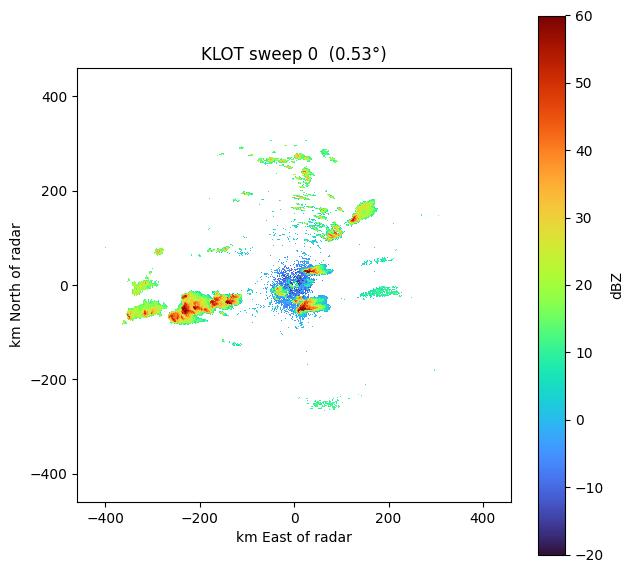

In [6]:
import matplotlib.pyplot as plt

if 'DBZH' in s0.data_vars:
    az_deg = np.asarray(s0['azimuth'].values)
    rng_m = np.asarray(s0['range'].values)
    dbzh = s0['DBZH'].values

    az_rad = np.deg2rad(az_deg)
    az_grid, rng_grid = np.meshgrid(az_rad, rng_m, indexing='ij')
    x = rng_grid * np.sin(az_grid) / 1000.0  # km East
    y = rng_grid * np.cos(az_grid) / 1000.0  # km North

    fig, ax = plt.subplots(figsize=(7, 7))
    pcm = ax.pcolormesh(x, y, dbzh, cmap='turbo', vmin=-20, vmax=60, shading='auto')
    ax.set_aspect('equal')
    ax.set_xlabel('km East of radar')
    ax.set_ylabel('km North of radar')
    ax.set_title(f"{dt.attrs.get('instrument_name', '')} sweep 0  ({s0.attrs.get('fixed_angle', '?'):.2f}°)")
    plt.colorbar(pcm, ax=ax, label='dBZ')
    plt.show()
else:
    print('No DBZH in sweep 0 (Doppler-only sweep?). Try /sweep_1 or another index.')

## 5. Speed: radish vs xradar

Both readers return an xarray DataTree with `/sweep_N` groups. Radish is currently 16–18× faster on this fixture because it goes through Rust + parallel bzip2 decompression.

In [7]:
import time

def time_n(label, fn, n=3):
    times = [(time.perf_counter(), fn() and time.perf_counter())[1] - t for t in [time.perf_counter() for _ in range(n)]]
    runs = []
    for _ in range(n):
        t = time.perf_counter()
        fn()
        runs.append(time.perf_counter() - t)
    runs.sort()
    median = runs[n // 2]
    print(f'  {label:<24} median={median:.3f}s  runs={[round(r,3) for r in runs]}')
    return median

rd_t = time_n('radish (engine=radish)',  lambda: xr.open_datatree(FIXTURE, engine='radish'))

try:
    import xradar
    xd_t = time_n('xradar.open_nexradlevel2', lambda: xradar.io.open_nexradlevel2_datatree(FIXTURE))
    print(f'\nspeedup: {xd_t / rd_t:.1f}×')
except ImportError:
    print('xradar not installed; skipping comparison.')

  radish (engine=radish)   median=0.163s  runs=[0.162, 0.163, 0.229]


  xradar.open_nexradlevel2 median=2.823s  runs=[2.796, 2.823, 2.881]

speedup: 17.3×


## 6. Parity spot-check vs xradar

Same physical ray (matched by azimuth) → same physical values. xradar uses `(azimuth, range)` dims while radish uses `(time, range)`, so we sort both sides by azimuth before comparing.

Conventions differ on the missing-data sentinel: xradar uses negative floats (e.g. -33 dBZ for below-threshold), radish uses NaN. We compare on the intersection of in-range valid gates.

In [8]:
try:
    import xradar
    xd = xradar.io.open_nexradlevel2_datatree(FIXTURE)

    rd_az = np.asarray(s0['azimuth'].values, dtype=np.float64)
    xd_az = np.asarray(xd['/sweep_0']['azimuth'].values, dtype=np.float64)
    rd_dbzh = np.asarray(s0['DBZH'].values, dtype=np.float64)[np.argsort(rd_az)]
    xd_dbzh = np.asarray(xd['/sweep_0']['DBZH'].values, dtype=np.float64)[np.argsort(xd_az)]

    if rd_dbzh.shape == xd_dbzh.shape:
        valid = (
            np.isfinite(rd_dbzh) & np.isfinite(xd_dbzh)
            & (rd_dbzh > -32.5) & (xd_dbzh > -32.5)
        )
        diff = rd_dbzh[valid] - xd_dbzh[valid]
        print(f'sweep_0 DBZH parity: {valid.sum():,} valid gates compared')
        print(f'  max |diff| = {np.abs(diff).max():.4f} dBZ')
        print(f'  mean diff  = {diff.mean():.4f} dBZ  (should be ~0)')
    else:
        print(f'shape mismatch: radish {rd_dbzh.shape} vs xradar {xd_dbzh.shape}  '
              '(likely AVSET truncation in one reader)')
except ImportError:
    print('xradar not installed; skipping comparison.')

sweep_0 DBZH parity: 178,185 valid gates compared
  max |diff| = 0.0000 dBZ
  mean diff  = 0.0000 dBZ  (should be ~0)


## 7. Format detection

The radish engine auto-detects `.ar2`/`.ar2v`, the AR2V magic bytes, and the canonical extensionless NEXRAD filename pattern. CfRadial1 NetCDF is also routed through the same engine.

In [9]:
from radish.backends.xarray_backend import _detect_format
for p in [str(FIXTURE), 'foo.ar2v', 'KATX20230520_201643_V06', 'foo.nc', 'random.txt']:
    print(f'  {p:<60} {_detect_format(p)}')

  /home/alfonso-ladino/python/raw2zarr/data/KLOT20260310_231412_V06 nexrad
  foo.ar2v                                                     nexrad
  KATX20230520_201643_V06                                      nexrad
  foo.nc                                                       cfradial1
  random.txt                                                   None


## 8. Lower-level Rust API (optional)

If you don't want xarray's wrap, the PyO3 layer is right there: `radish.read_nexrad(path)` returns a `VolumeData` you can index. Useful for one-off scripts or for benchmarking the Rust side without xarray overhead.

In [10]:
import radish
vol = radish.read_nexrad(str(FIXTURE))
print(f'Volume: {vol.metadata.instrument_name}, {vol.num_sweeps} sweeps')
sweep0 = vol.get_sweep(0)
print(f'sweep 0: rays={sweep0.num_rays} gates={sweep0.num_gates}  moments={sweep0.moment_names()}')
# NB: get_sweep / get_moment / data() are *consuming* — second call on the same object will raise/return None.

Volume: KLOT, 19 sweeps
sweep 0: rays=720 gates=1832  moments=['DBZH', 'PHIDP', 'RHOHV', 'ZDR']
